# Principal Component Analysis (PCA)

### Aim
To apply Principal Component Analysis (PCA) on a multivariate dataset to reduce its dimensionality, visualize the data in lower dimensions, and evaluate the amount of variance retained after transformation.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## Create Dataset

In [2]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)

df

,Height,Weight,Age,Gender
0,170,65,30,1
1,165,59,25,0
2,180,75,35,1
3,175,68,28,1
4,160,55,22,0
5,172,70,32,1
6,168,62,27,0
7,177,74,33,1
8,162,58,24,0
9,158,54,21,0


## Separate Features and Target

In [3]:
X = df.drop('Gender', axis=1)
y = df['Gender']

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Height  Weight  Age
0     170      65   30
1     165      59   25
2     180      75   35
3     175      68   28
4     160      55   22
5     172      70   32
6     168      62   27
7     177      74   33
8     162      58   24
9     158      54   21

Target:
0    1
1    0
2    1
3    1
4    0
5    1
6    0
7    1
8    0
9    0
Name: Gender, dtype: int64


## Standardize the Data

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[ 0.18419807  0.13867505  0.50910379]
 [-0.52425605 -0.69337525 -0.59764358]
 [ 1.60110632  1.52542554  1.61585117]
 [ 0.8926522   0.5547002   0.06640484]
 [-1.23271018 -1.24807544 -1.26169201]
 [ 0.46757972  0.83205029  0.95180275]
 [-0.09918358 -0.2773501  -0.15494463]
 [ 1.17603385  1.38675049  1.17315222]
 [-0.94932853 -0.83205029 -0.81899306]
 [-1.51609183 -1.38675049 -1.48304149]]


In [6]:
print("Mean:", X_scaled.mean(axis=0))

Mean: [ 1.59872116e-15 -4.44089210e-17  1.55431223e-16]


## Apply PCA

In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (10, 3)
PCA shape: (10, 2)


## Display Principal Components

In [8]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

pca_df

,Principal Component 1,Principal Component 2
0,0.479350,0.240059
1,-1.048541,-0.046208
2,2.737638,0.017043
3,0.874626,-0.586085
4,-2.160684,-0.022405
5,1.300132,0.336909
6,-0.307430,-0.032200
7,2.157779,-0.010548
8,-1.501153,0.088028
9,-2.531716,0.015408


## Explained Variance

In [9]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_variance)

Explained variance ratio:
[0.97871061 0.01755646]


## Percentage of Variance

In [10]:
print("PC1 variance:", explained_variance[0] * 100, "%")
print("PC2 variance:", explained_variance[1] * 100, "%")

total_variance = explained_variance.sum() * 100

print("Total variance retained:", total_variance, "%")

PC1 variance: 97.8710613742194 %
PC2 variance: 1.7556459483300046 %
Total variance retained: 99.62670732254941 %


## Variance Visualization

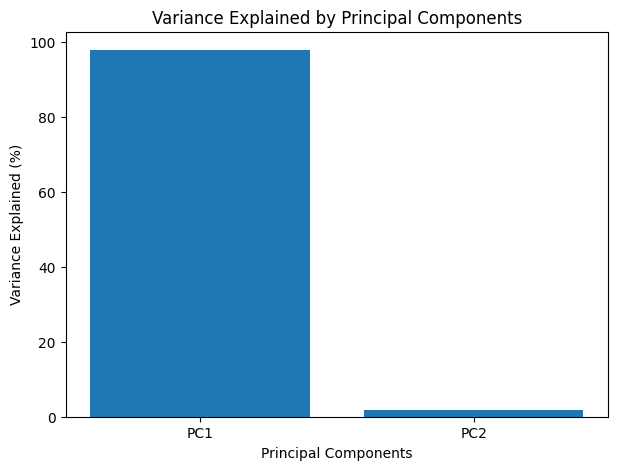

In [11]:
plt.figure(figsize=(7, 5))

components = ['PC1', 'PC2']

plt.bar(components, explained_variance * 100)

plt.xlabel('Principal Components')
plt.ylabel('Variance Explained (%)')
plt.title('Variance Explained by Principal Components')

plt.show()

## Cumulative Variance

In [13]:
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative variance:")
print(cumulative_variance * 100)

Cumulative variance:
[97.87106137 99.62670732]


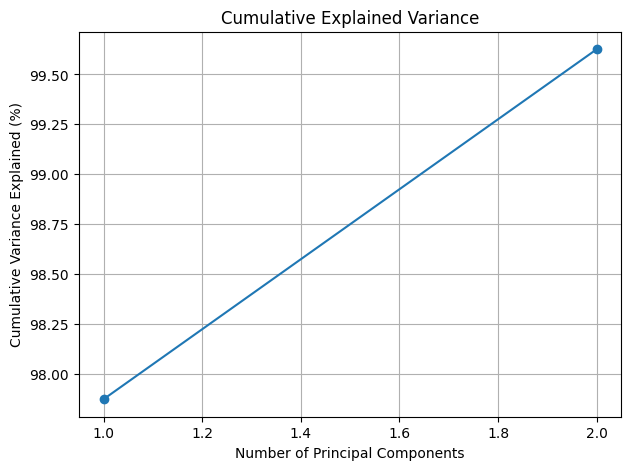

In [14]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker='o'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('Cumulative Explained Variance')

plt.grid()
plt.show()

## Before PCA Visualization

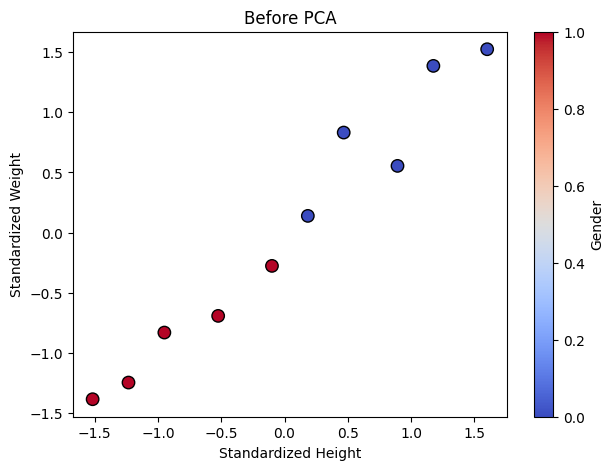

In [15]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(7, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Standardized Height')
plt.ylabel('Standardized Weight')
plt.title('Before PCA')

plt.colorbar(label='Gender')

plt.show()

## After PCA Visualization

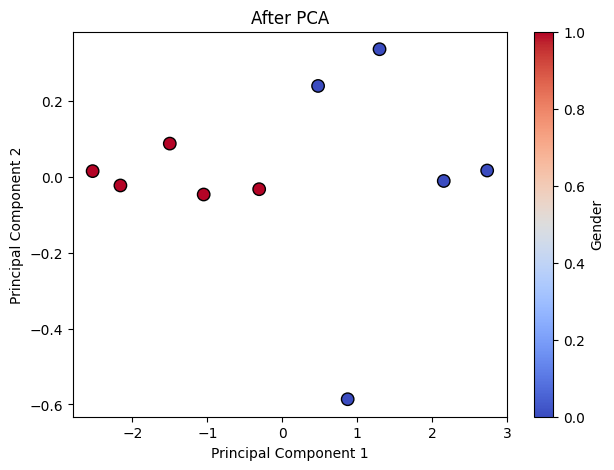

In [16]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA')

plt.colorbar(label='Gender')

plt.show()

## Train/Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7, 2)
Testing data: (3, 2)


## Logistic Regression

In [18]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted values:", y_pred)
print("Actual values:", y_test.values)

Predicted values: [0 0 1]
Actual values: [0 0 1]


## Confusion Matrix

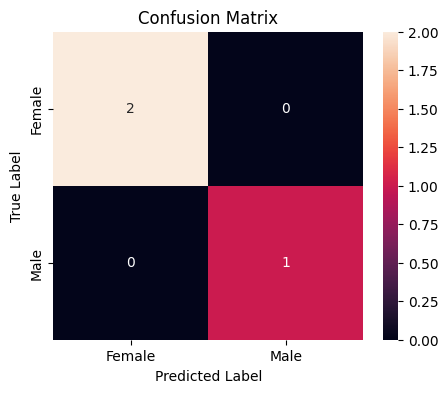

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

## Conclusion

PCA was successfully applied to the multivariate dataset. The original three features (Height, Weight and Age) were standardized and transformed into two principal components. The explained variance ratio was calculated to determine the amount of information retained after dimensionality reduction.

The PCA transformation reduced the dimensionality of the dataset while retaining a significant amount of the original variance. The 2D visualization made it easier to understand the distribution of the data. PCA can therefore be used to reduce computational complexity and simplify high-dimensional datasets while minimizing information loss.